In [2]:
import numpy as np
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import  LabelEncoder

In [3]:
data = pd.read_csv('SeoulBikeData.csv', encoding= 'unicode_escape')
data.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [4]:
print("Duplicate entry in data:",len(data[data.duplicated()])) 

Duplicate entry in data: 0


In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Rented Bike Count,8760.0,704.602055,644.997468,0.0,191.00,504.50,1065.25,3556.00
Hour,8760.0,11.500000,6.922582,0.0,5.75,11.50,17.25,23.00
Temperature(°C),8760.0,12.882922,11.944825,-17.8,3.50,13.70,22.50,39.40
Humidity(%),8760.0,58.226256,20.362413,0.0,42.00,57.00,74.00,98.00
Wind speed (m/s),8760.0,1.724909,1.036300,0.0,0.90,1.50,2.30,7.40
Visibility (10m),8760.0,1436.825799,608.298712,27.0,940.00,1698.00,2000.00,2000.00
Dew point temperature(°C),8760.0,4.073813,13.060369,-30.6,-4.70,5.10,14.80,27.20
Solar Radiation (MJ/m2),8760.0,0.569111,0.868746,0.0,0.00,0.01,0.93,3.52
Rainfall(mm),8760.0,0.148687,1.128193,0.0,0.00,0.00,0.00,35.00
Snowfall (cm),8760.0,0.075068,0.436746,0.0,0.00,0.00,0.00,8.80


In [6]:
print(data.shape)

(8760, 14)


In [7]:
# Grouping by functioning day and calculating the total Rented Bike Count
data.groupby('Functioning Day').sum()['Rented Bike Count']

Functioning Day
No           0
Yes    6172314
Name: Rented Bike Count, dtype: int64

In [8]:
#Since we only consider the functioning day here.
data2 = data[data['Functioning Day'] == 'Yes']
data2 = data2.drop(columns=['Functioning Day'])
data2.shape


(8465, 13)

In [9]:
protion_of_functioning_day = data2.shape[0] / data.shape[0]
print("Protion of Functioning Day in the whole data:", protion_of_functioning_day)

Protion of Functioning Day in the whole data: 0.966324200913242


In [10]:
#date time conversion
data2['Date'] = pd.to_datetime(data2['Date'],format='%d/%m/%Y') 
data2['Date']

0      2017-12-01
1      2017-12-01
2      2017-12-01
3      2017-12-01
4      2017-12-01
          ...    
8755   2018-11-30
8756   2018-11-30
8757   2018-11-30
8758   2018-11-30
8759   2018-11-30
Name: Date, Length: 8465, dtype: datetime64[ns]

In [11]:
#Seperate Day, Month, Year from DataFrame Column
data2['Day'] = data2['Date'].dt.day
data2['Month'] = data2['Date'].dt.month
data2['Year'] = data2['Date'].dt.year
data2['day_of_week'] = data2['Date'].dt.dayofweek
data2['is_weekend'] = data2['day_of_week'].isin([5,6]).astype(int)
data2.drop(columns='Date', inplace= True)
data2.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Day,Month,Year,day_of_week,is_weekend
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,1,12,2017,4,0


In [12]:
#Some preprocessing work: ONE-HOT ENCODING for categorical variables
numerical_features=[col for col in data2.columns if data2[col].dtype!='O']
num_data = data2[numerical_features]
categorical_features = ['Seasons', 'Holiday']
cat_data = data2[categorical_features]
numerical_features

['Rented Bike Count',
 'Hour',
 'Temperature(°C)',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature(°C)',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)',
 'Day',
 'Month',
 'Year',
 'day_of_week',
 'is_weekend']

In [13]:
#Some analysis on categorical variables
data.groupby('Seasons').sum()['Rented Bike Count'].sort_values(ascending = False).reset_index()

,Seasons,Rented Bike Count
0,Summer,2283234
1,Autumn,1790002
2,Spring,1611909
3,Winter,487169


In [14]:
data.groupby('Holiday').sum()['Rented Bike Count'].sort_values(ascending = False).reset_index()

,Holiday,Rented Bike Count
0,No Holiday,5956419
1,Holiday,215895


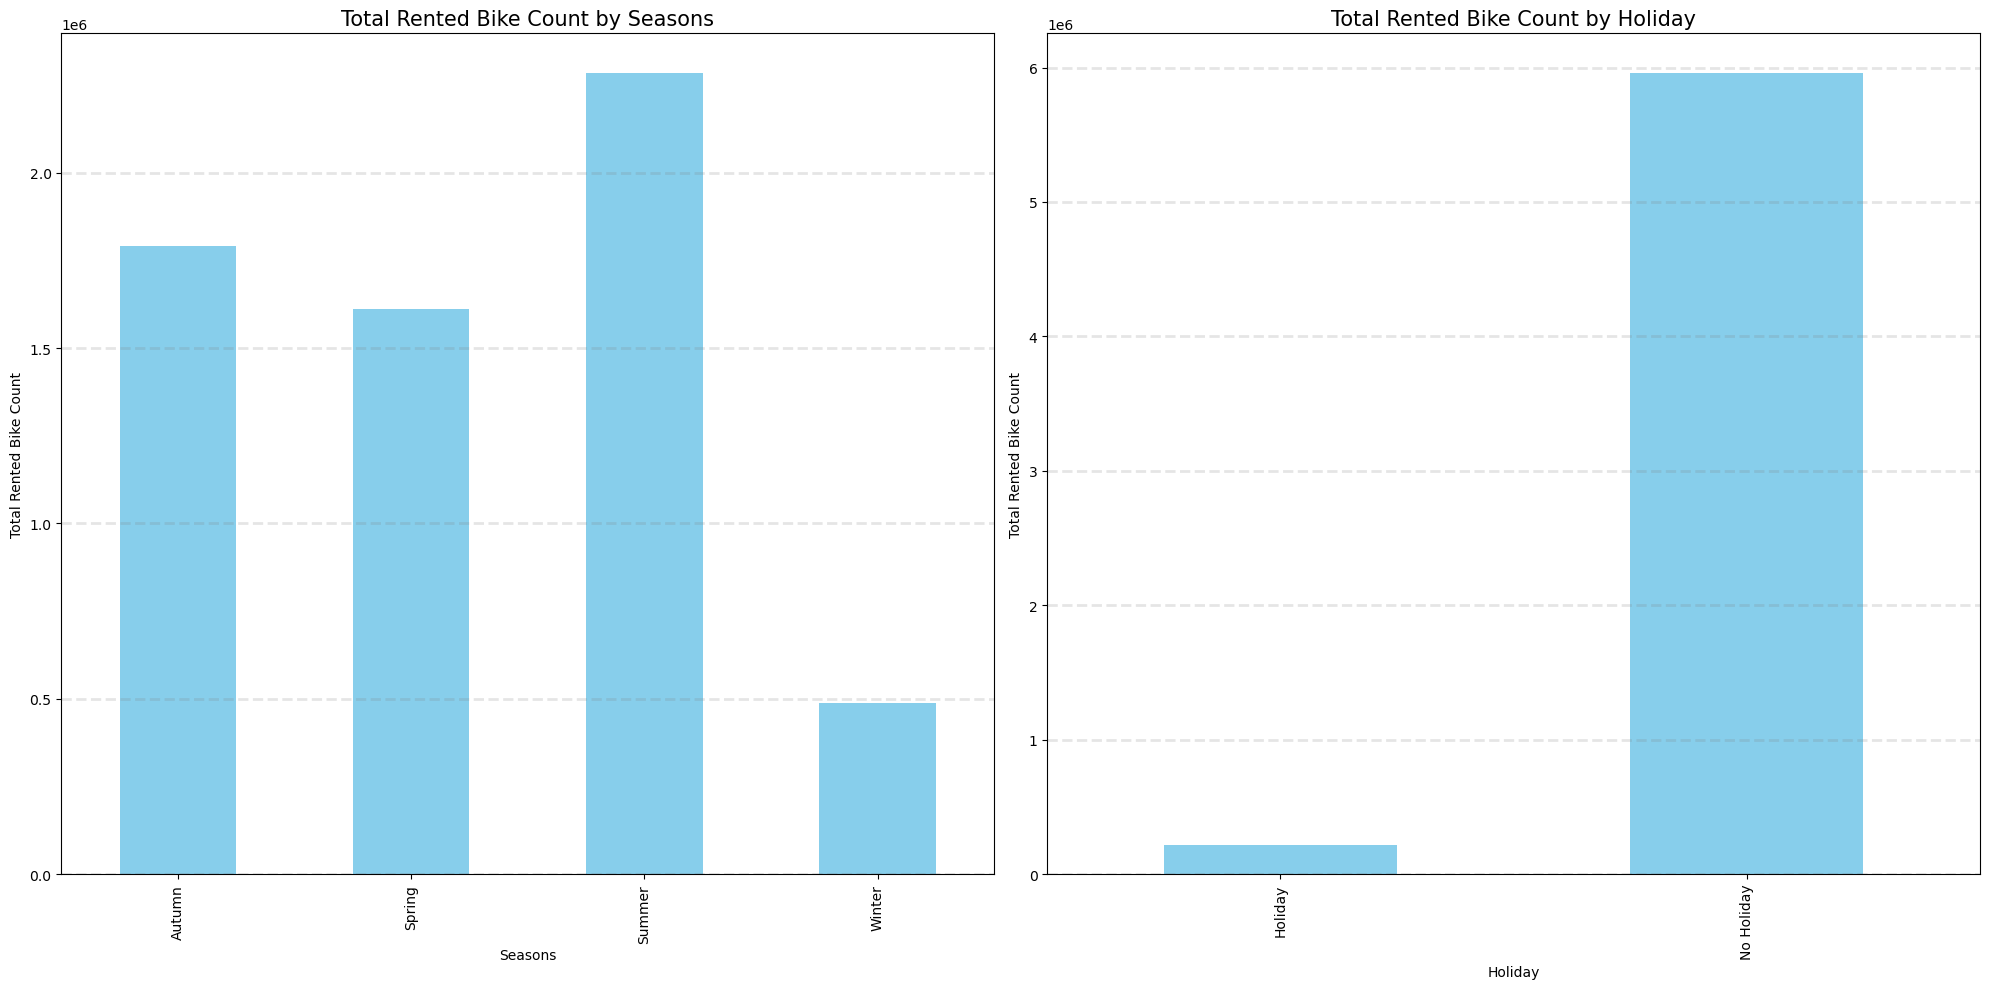

In [15]:
fig = plt.figure(figsize = (20,10))
for index,column in enumerate(categorical_features) :
    plt.subplot(1,2,index+1)
    dataset=data2.copy()
    feature = data2[column]
    dataset.groupby(feature)['Rented Bike Count'].sum().plot(kind='bar',color='skyblue')
  
    ax = fig.gca()
    plt.title(f'Total Rented Bike Count by {column}', fontsize=15)
    plt.ylabel('Total Rented Bike Count')
    plt.tight_layout()
    plt.grid(color='grey', linestyle='--', linewidth=2, axis='y', alpha=0.2)


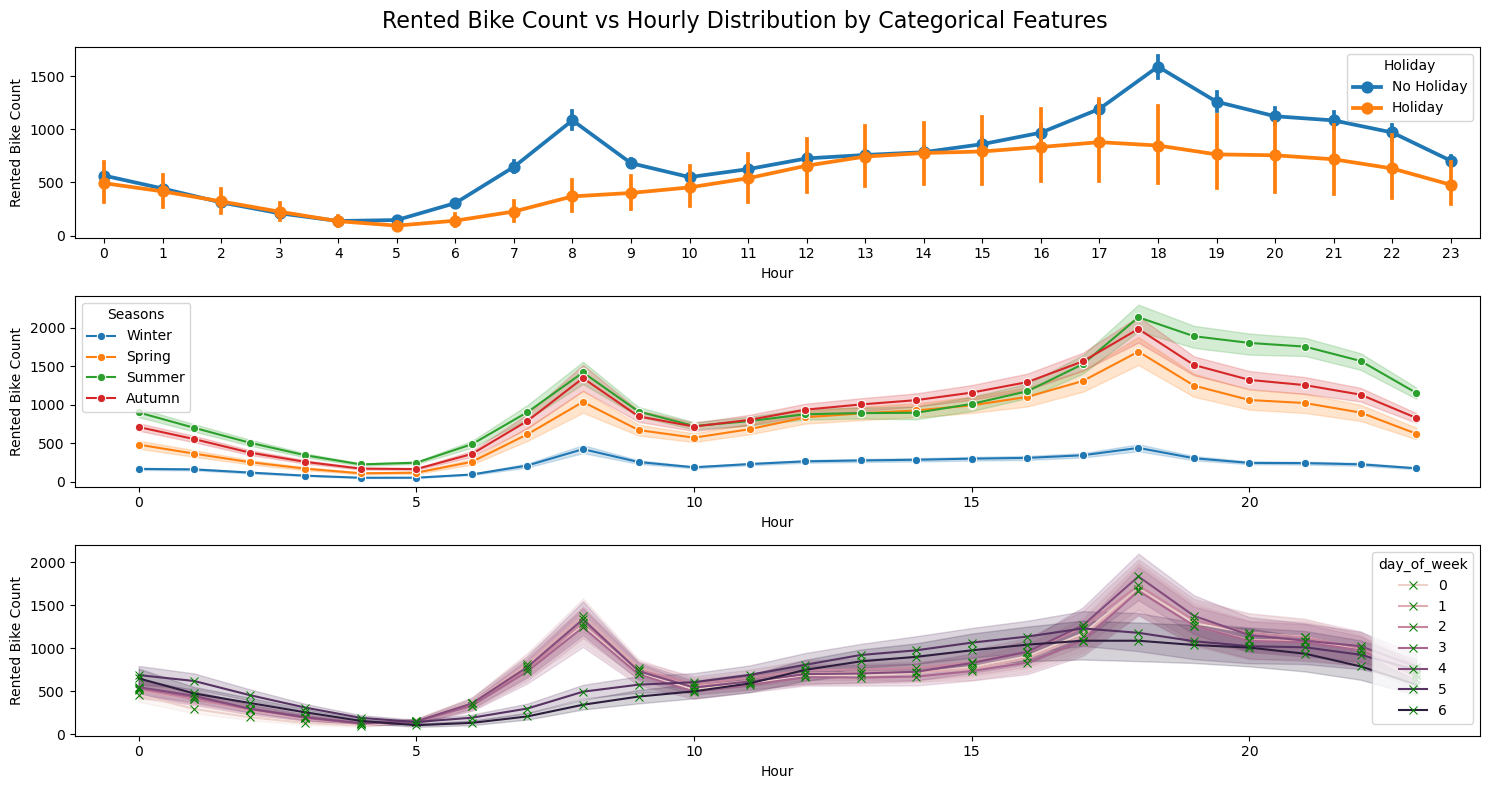

In [16]:
fig, axs = plt.subplots(nrows=3,ncols=1,figsize=(15,8), dpi=100)
sns.pointplot(data=dataset, x="Hour", y="Rented Bike Count", ax=axs[0], 
              hue="Holiday")
sns.lineplot(data=dataset, x="Hour", y="Rented Bike Count", ax=axs[1], 
              hue="Seasons", marker="o")
sns.lineplot(data=dataset, x="Hour", y="Rented Bike Count", ax=axs[2],
              hue="day_of_week", marker="x",markeredgecolor='green')
plt.suptitle('Rented Bike Count vs Hourly Distribution by Categorical Features', fontsize=16)
plt.tight_layout()

#preprocess
In this situation, we have two options here, one is one_hot encoder and the other I found is labeling.
One_hot encoder here will create 6 coloumns of is_seasons and is_holidays. 

In [17]:
#ONE HOT ENCODING for categorical variables
data_encoded = pd.get_dummies(data2, columns=categorical_features, drop_first=True)
data_encoded.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Day,Month,Year,day_of_week,is_weekend,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1,12,2017,4,0,False,False,True,True
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1,12,2017,4,0,False,False,True,True
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1,12,2017,4,0,False,False,True,True
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1,12,2017,4,0,False,False,True,True
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1,12,2017,4,0,False,False,True,True


In [18]:
#Labeling for categorical variables
data_labeled = data2.apply(LabelEncoder().fit_transform)
data_labeled.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Day,Month,Year,day_of_week,is_weekend
0,252,0,111,28,22,1779,114,0,0,0,3,1,0,11,0,4,0
1,202,1,108,29,8,1779,114,0,0,0,3,1,0,11,0,4,0
2,171,2,103,30,10,1779,113,0,0,0,3,1,0,11,0,4,0
3,105,3,101,31,9,1779,114,0,0,0,3,1,0,11,0,4,0
4,76,4,103,27,23,1779,104,0,0,0,3,1,0,11,0,4,0


## EDA
After doing simple check and drop some unnecessary data, we are going to work on the EDA

In [19]:
data2.describe().T

,count,mean,std,min,25%,50%,75%,max
Rented Bike Count,8465.0,729.156999,642.351166,2.0,214.0,542.00,1084.00,3556.00
Hour,8465.0,11.507029,6.920899,0.0,6.0,12.00,18.00,23.00
Temperature(°C),8465.0,12.771057,12.104375,-17.8,3.0,13.50,22.70,39.40
Humidity(%),8465.0,58.147194,20.484839,0.0,42.0,57.00,74.00,98.00
Wind speed (m/s),8465.0,1.725883,1.034281,0.0,0.9,1.50,2.30,7.40
Visibility (10m),8465.0,1433.873479,609.051229,27.0,935.0,1690.00,2000.00,2000.00
Dew point temperature(°C),8465.0,3.944997,13.242399,-30.6,-5.1,4.70,15.20,27.20
Solar Radiation (MJ/m2),8465.0,0.567868,0.868245,0.0,0.0,0.01,0.93,3.52
Rainfall(mm),8465.0,0.149120,1.125540,0.0,0.0,0.00,0.00,35.00
Snowfall (cm),8465.0,0.077685,0.444063,0.0,0.0,0.00,0.00,8.80


<Axes: >

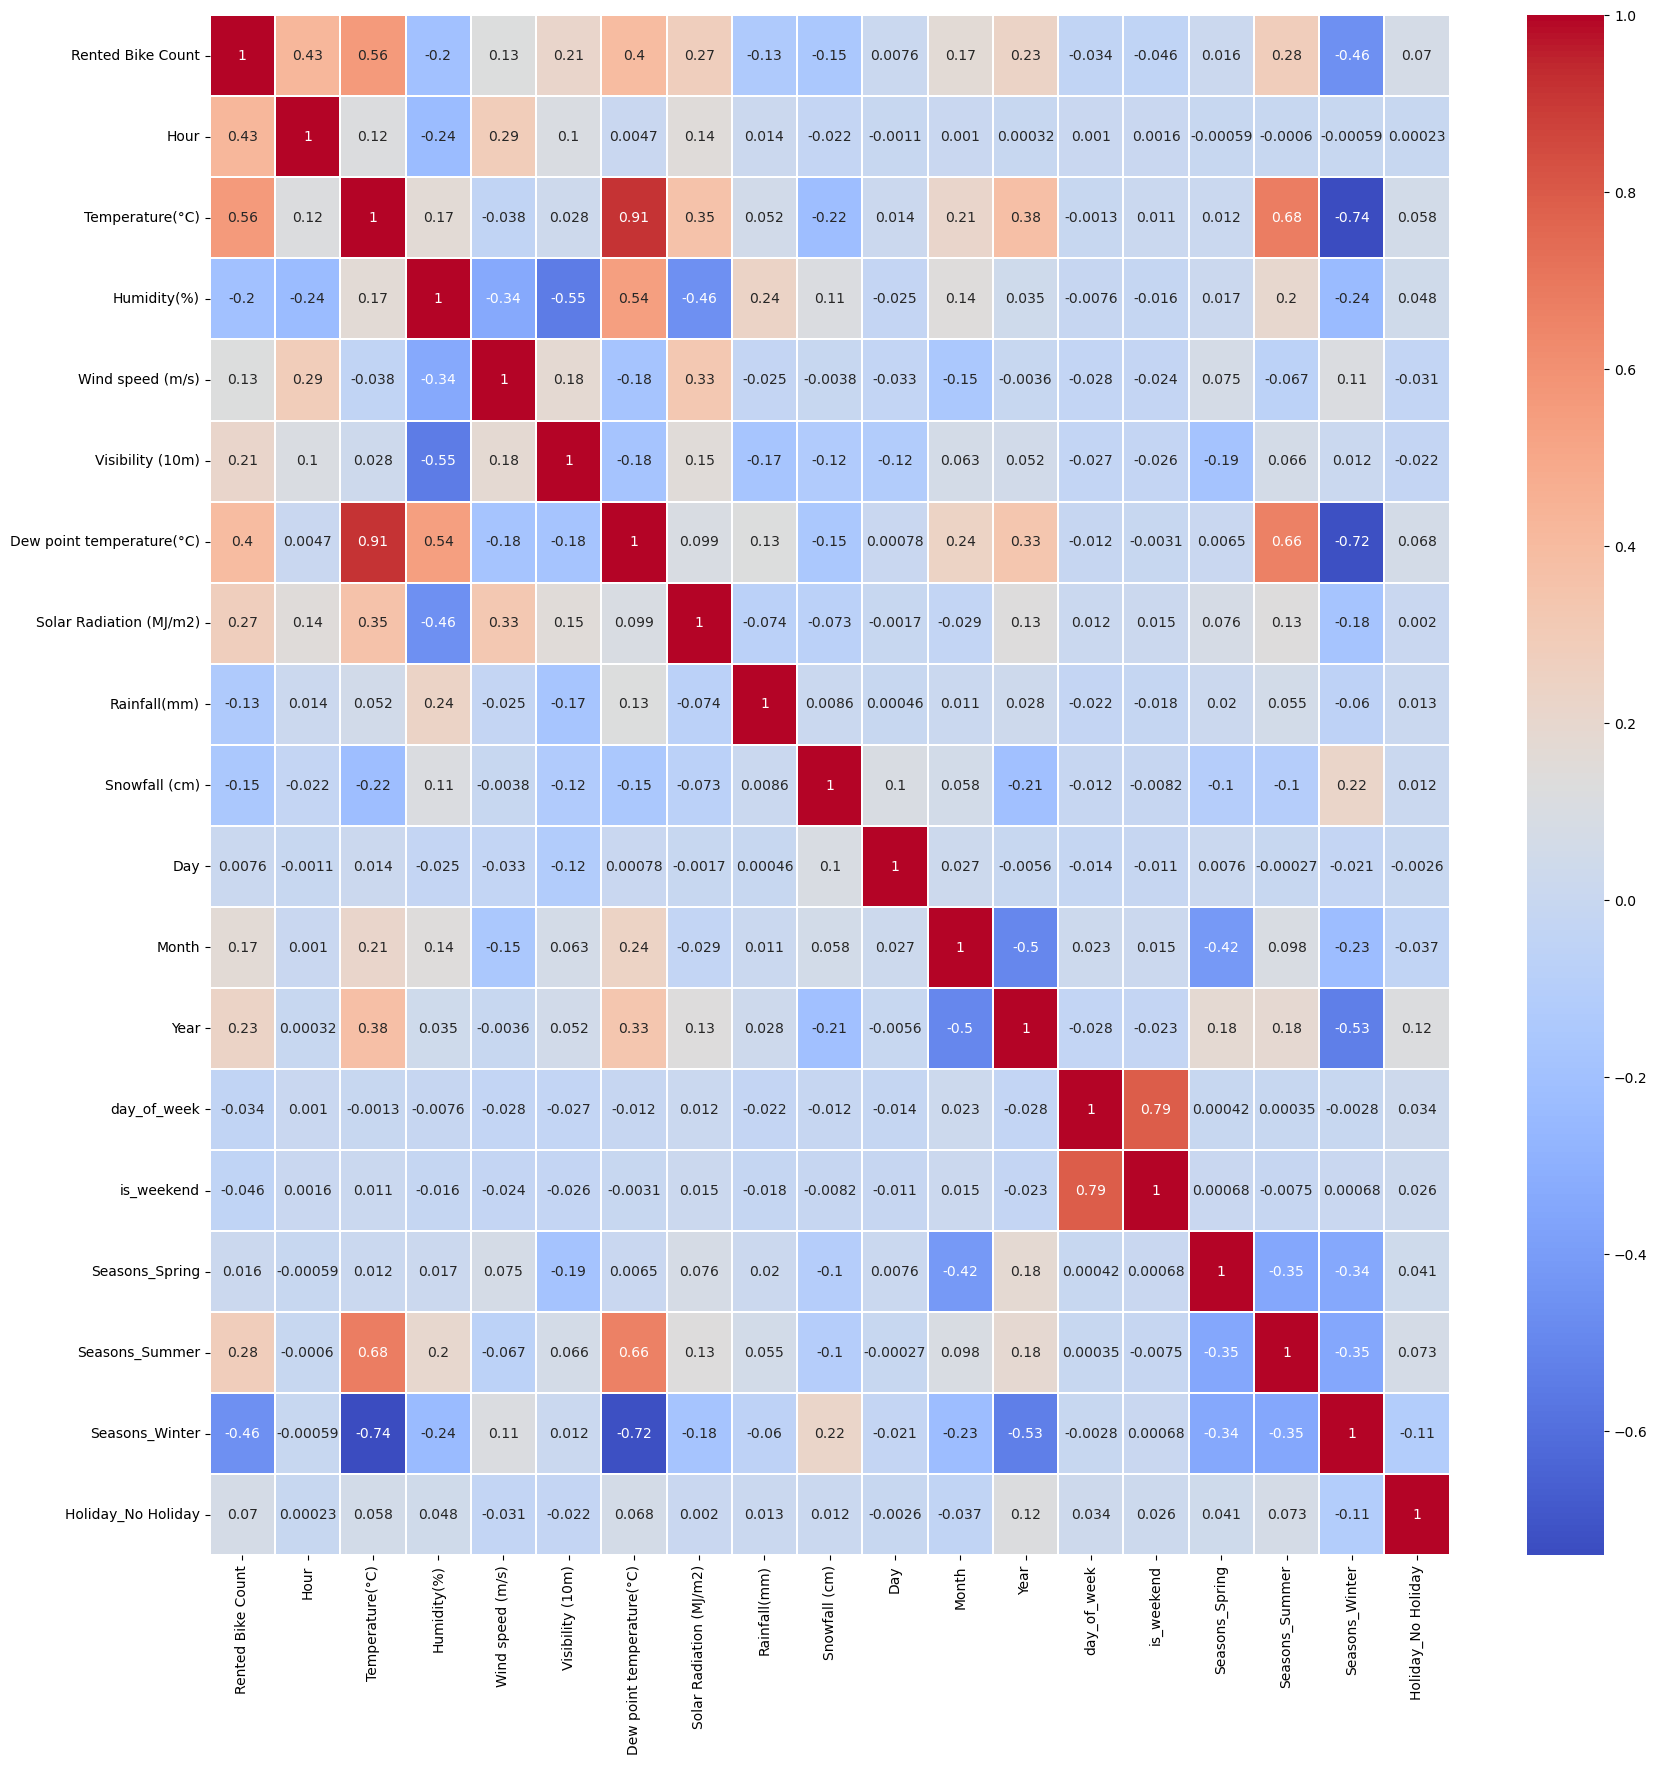

In [20]:

#Working on Correlation Matrix
corr = data_encoded.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.1, annot=True, linecolor='white')

<Axes: >

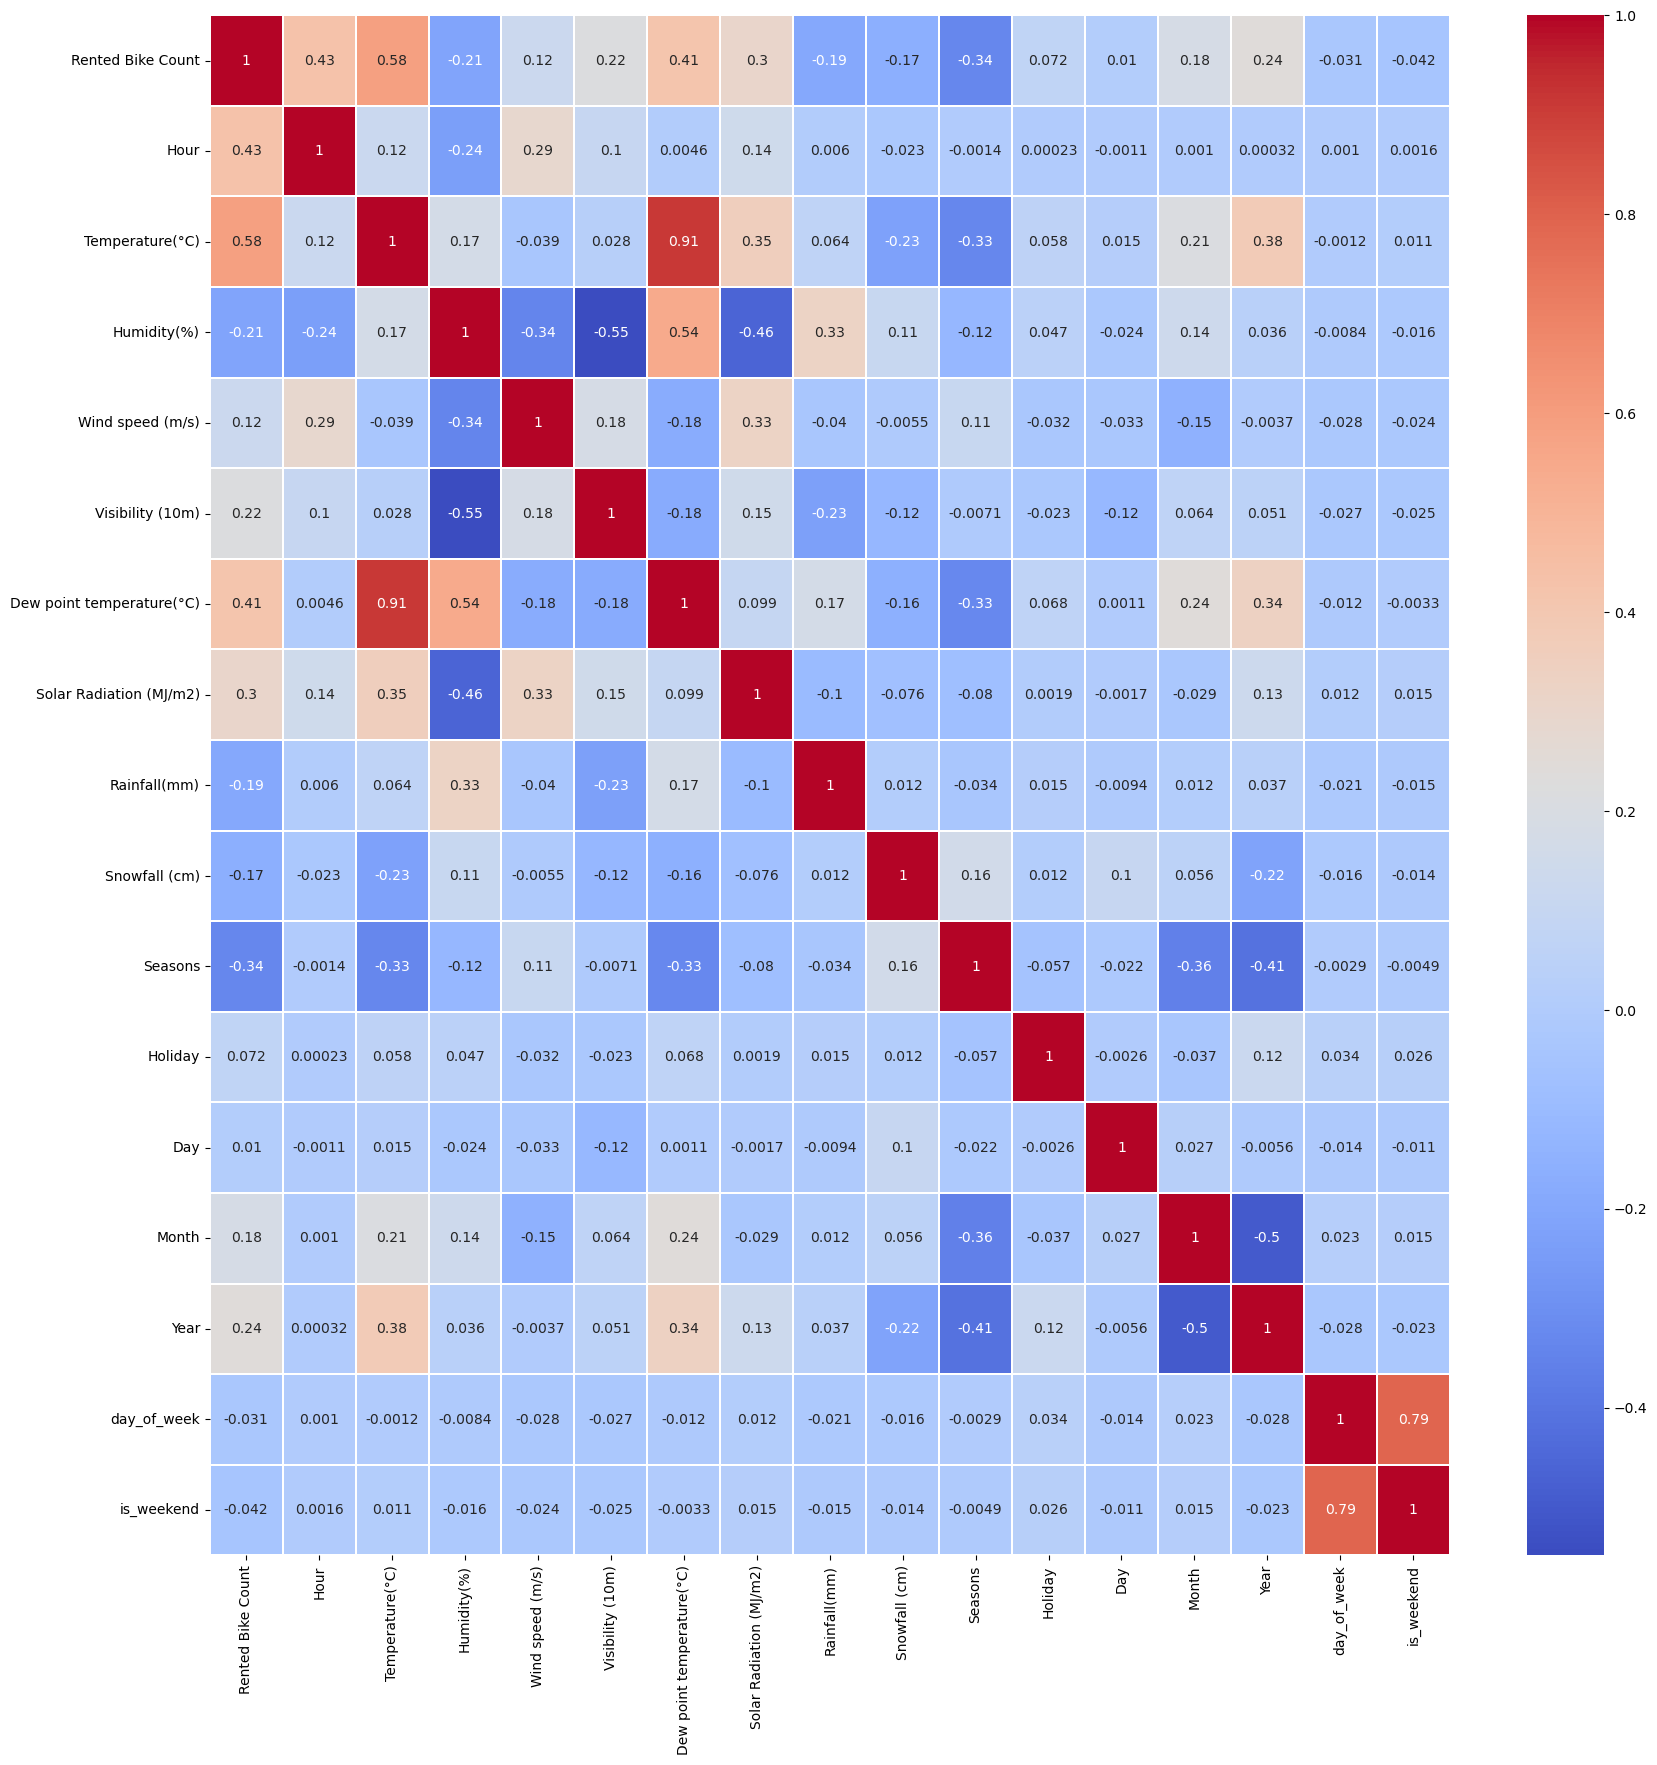

In [21]:
corr = data_labeled.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.1, annot=True, linecolor='white')

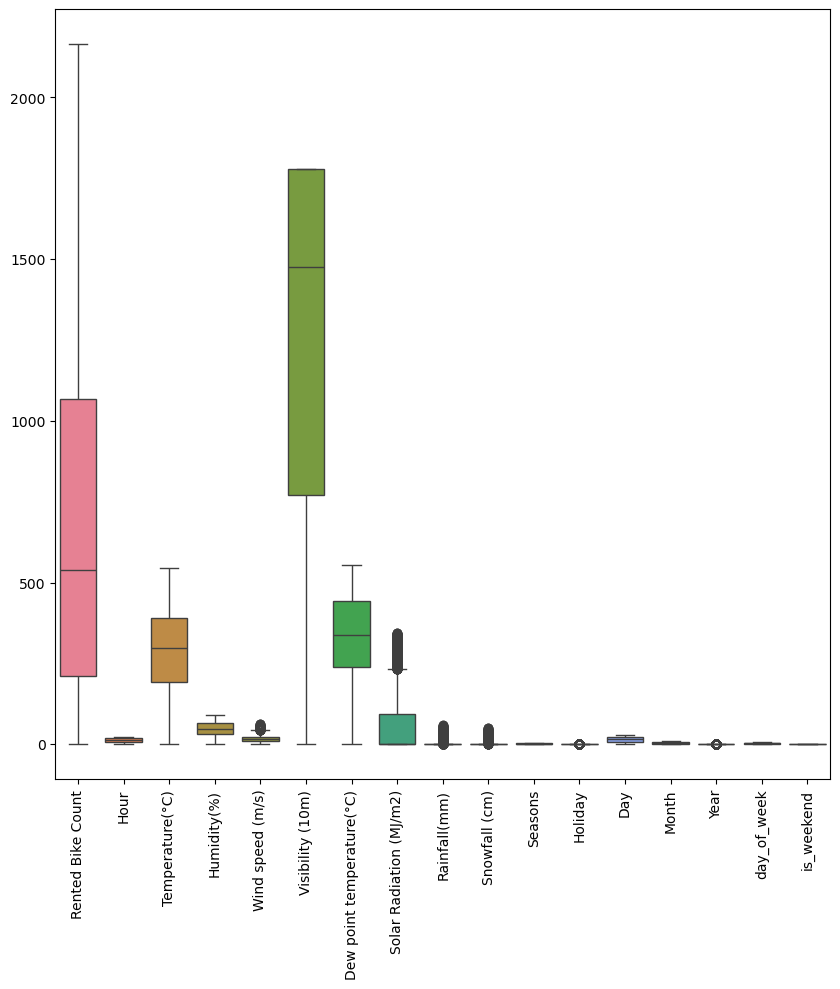

In [ ]:
#checking for outliers
plt.figure(figsize=(10,10))   # for define chart size
plt.xticks(rotation =90)     #plot X-axis ticks in 90 degree rotation for clear visible
sns.boxplot(data = data_labeled)    #box plot of data_labeled data frame raw data
plt.show()

In [23]:
#check for skewness
data_labeled.skew()

Rented Bike Count            0.793815
Hour                        -0.001261
Temperature(°C)             -0.171558
Humidity(%)                  0.084804
Wind speed (m/s)             0.861648
Visibility (10m)            -0.673947
Dew point temperature(°C)   -0.334545
Solar Radiation (MJ/m2)      1.509173
Rainfall(mm)                 7.130751
Snowfall (cm)                7.034251
Seasons                     -0.048455
Holiday                     -4.219538
Day                         -0.018521
Month                        0.034041
Year                        -2.911538
day_of_week                 -0.015989
is_weekend                   0.934539
dtype: float64

Text(0.5, 0.98, 'Distribution and Skewness of Features')

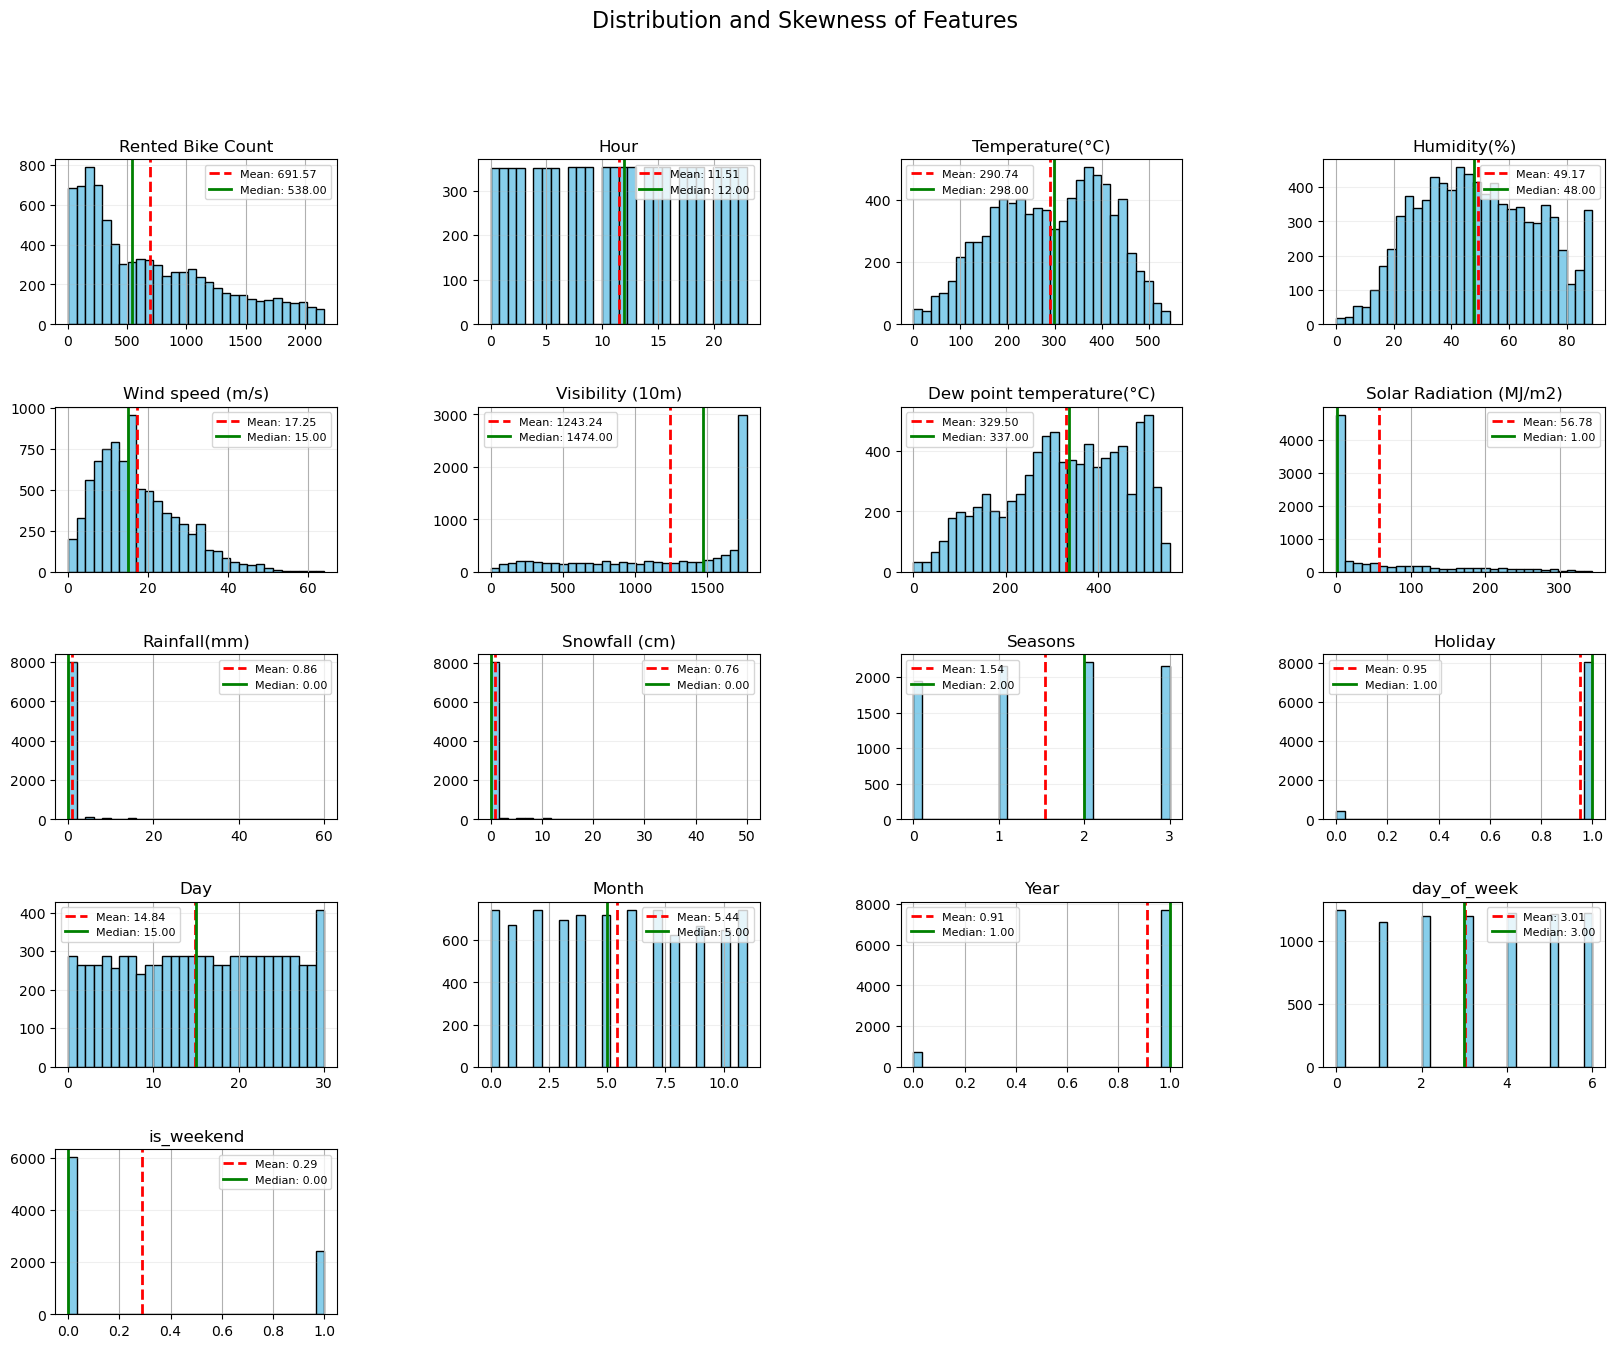

In [24]:
#visualization of skewness with bigger spaces between histograms
axes = data_labeled.hist(bins=30, edgecolor='black', color='skyblue', figsize=(20,15))
for ax_ in axes.ravel():
    col = ax_.get_title()
    if not col or col not in data_labeled.columns:
        continue
    s = data_labeled[col].dropna()
    mean_val = s.mean()
    median_val = s.median()
    ax_.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax_.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
    ax_.legend(fontsize=8)
    ax_.grid(axis='y', alpha=0.2)

plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.suptitle('Distribution and Skewness of Features', fontsize=16)


# Splitting

In [25]:
# Time series splitting, the data is sorted by date and hour already by the source dataset
# Use the original sequence for splitting
train_size = int(len(data2) * 0.7)
train_data = data2.iloc[:train_size]
test_data = data2.iloc[train_size:]
train_data.shape, test_data.shape


((5925, 17), (2540, 17))

In [61]:
#Sklearn time series train test split
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(data_labeled):
    X_train, X_test = data_labeled.iloc[train_index], data_labeled.iloc[test_index]
    print("TRAIN indices:", train_index, "TEST indices:", test_index) 

TRAIN indices: [   0    1    2 ... 1412 1413 1414] TEST indices: [1415 1416 1417 ... 2822 2823 2824]
TRAIN indices: [   0    1    2 ... 2822 2823 2824] TEST indices: [2825 2826 2827 ... 4232 4233 4234]
TRAIN indices: [   0    1    2 ... 4232 4233 4234] TEST indices: [4235 4236 4237 ... 5642 5643 5644]
TRAIN indices: [   0    1    2 ... 5642 5643 5644] TEST indices: [5645 5646 5647 ... 7052 7053 7054]
TRAIN indices: [   0    1    2 ... 7052 7053 7054] TEST indices: [7055 7056 7057 ... 8462 8463 8464]


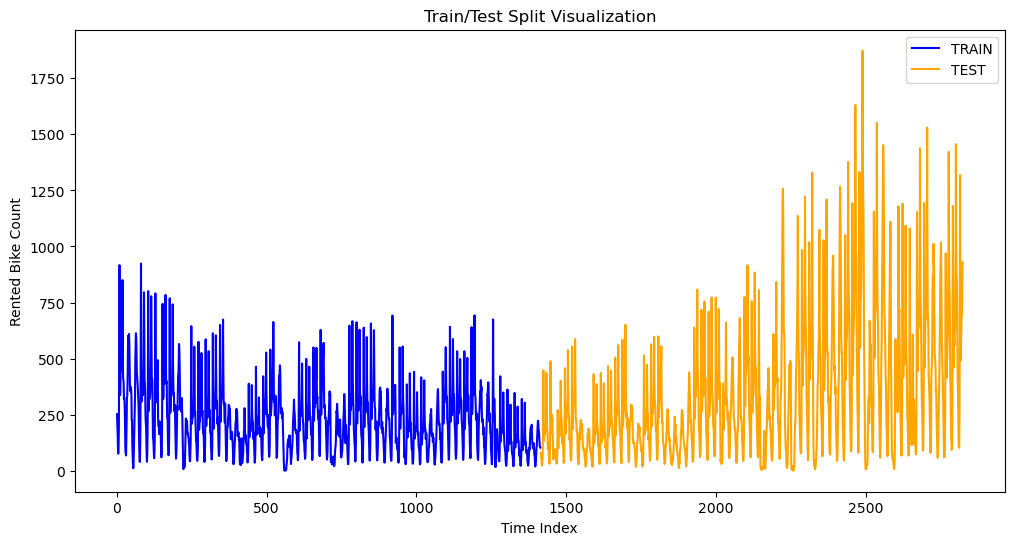

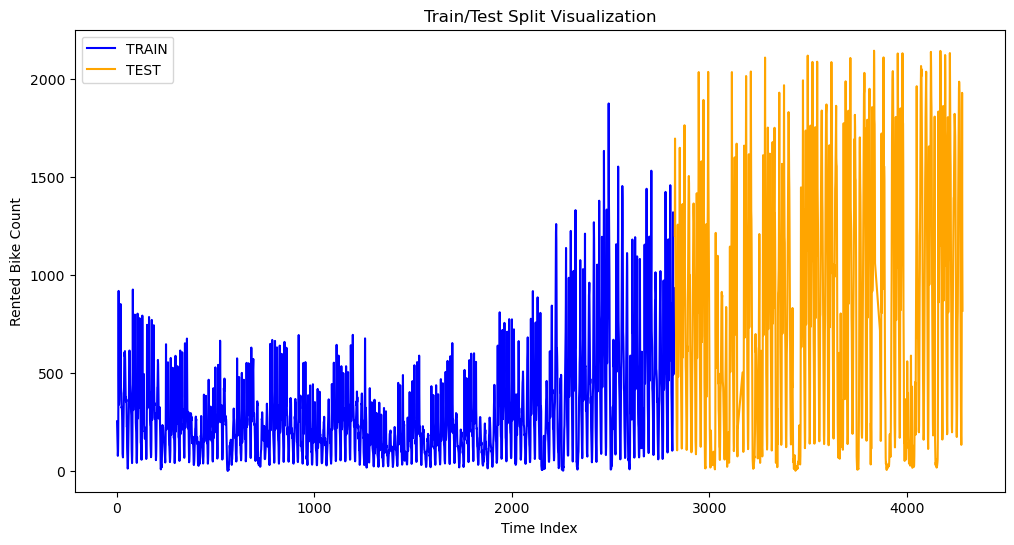

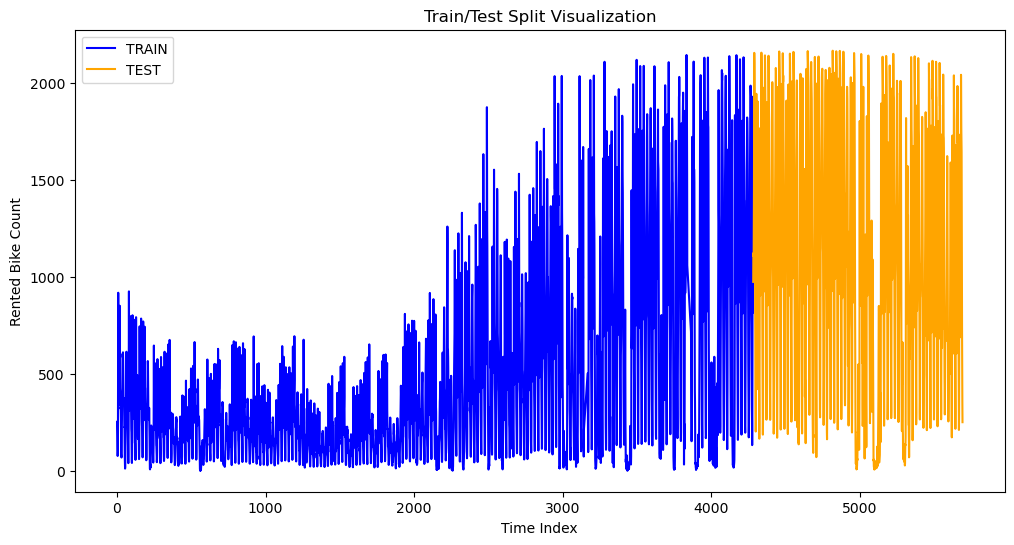

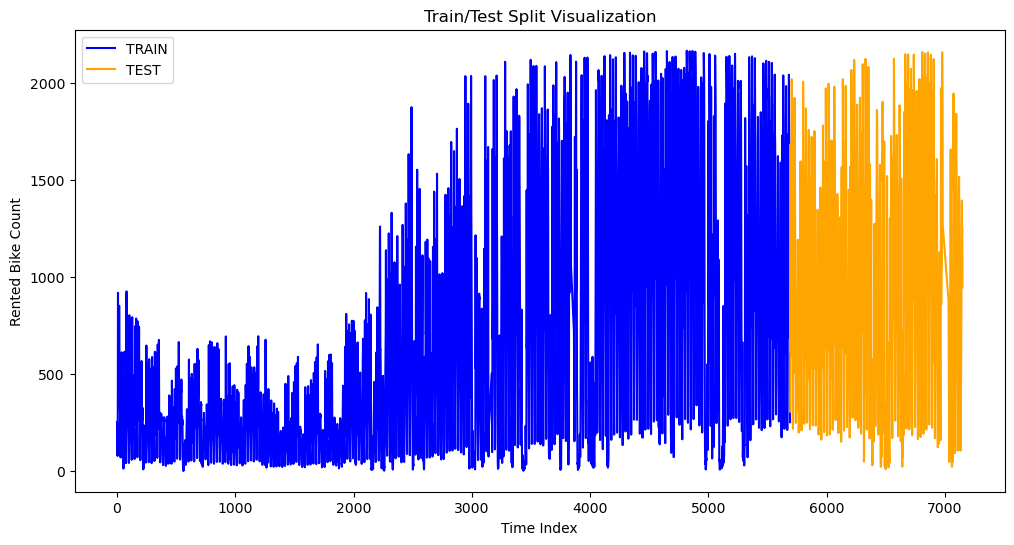

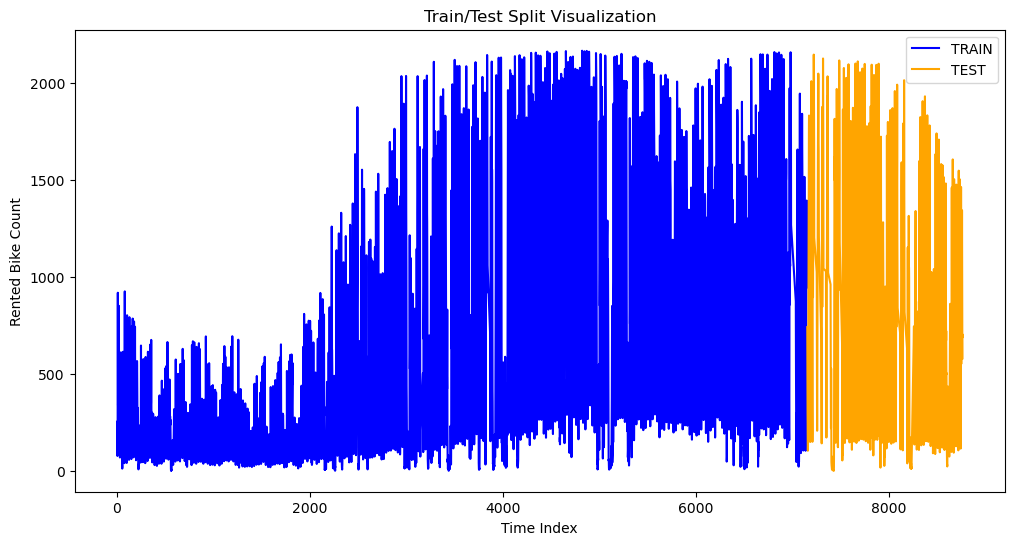

In [ ]:
#visualize the splits
import matplotlib.pyplot as plt

for train_index, test_index in tscv.split(data_labeled):
    plt.figure(figsize=(12, 6))
    plt.plot(data_labeled['Rented Bike Count'].index[train_index], data_labeled['Rented Bike Count'].iloc[train_index], label='TRAIN_VAL', color='blue')
    plt.plot(data_labeled['Rented Bike Count'].index[test_index], data_labeled['Rented Bike Count'].iloc[test_index], label='TEST', color='orange')
    plt.title('Train/Test Split Visualization')
    plt.xlabel('Time Index')
    plt.ylabel('Rented Bike Count')
    plt.legend()
    plt.show()


In [38]:
#time series splitting with seasonal blocks
seasons = data_labeled['Seasons'].unique()
seasonal_splits = []
for season in seasons:
    season_data = data_labeled[data_labeled['Seasons'] == season]
    tscv = TimeSeriesSplit(n_splits=3)
    for train_index, test_index in tscv.split(season_data):
        seasonal_splits.append((season_data.iloc[train_index], season_data.iloc[test_index]))
for i, (train_season, test_season) in enumerate(seasonal_splits):
    print(f"Split {i+1} - Season: {train_season['Seasons'].iloc[0]}")
    print("TRAIN shape:", train_season.shape)
    print("TEST shape:", test_season.shape)


Split 1 - Season: 3
TRAIN shape: (540, 17)
TEST shape: (540, 17)
Split 2 - Season: 3
TRAIN shape: (1080, 17)
TEST shape: (540, 17)
Split 3 - Season: 3
TRAIN shape: (1620, 17)
TEST shape: (540, 17)
Split 4 - Season: 1
TRAIN shape: (540, 17)
TEST shape: (540, 17)
Split 5 - Season: 1
TRAIN shape: (1080, 17)
TEST shape: (540, 17)
Split 6 - Season: 1
TRAIN shape: (1620, 17)
TEST shape: (540, 17)
Split 7 - Season: 2
TRAIN shape: (552, 17)
TEST shape: (552, 17)
Split 8 - Season: 2
TRAIN shape: (1104, 17)
TEST shape: (552, 17)
Split 9 - Season: 2
TRAIN shape: (1656, 17)
TEST shape: (552, 17)
Split 10 - Season: 0
TRAIN shape: (485, 17)
TEST shape: (484, 17)
Split 11 - Season: 0
TRAIN shape: (969, 17)
TEST shape: (484, 17)
Split 12 - Season: 0
TRAIN shape: (1453, 17)
TEST shape: (484, 17)


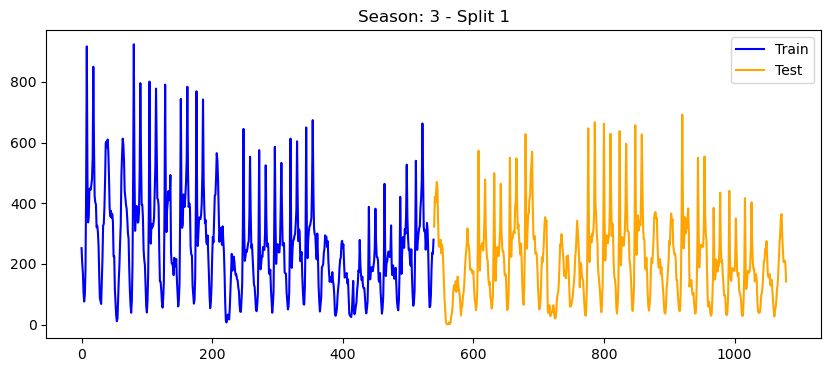

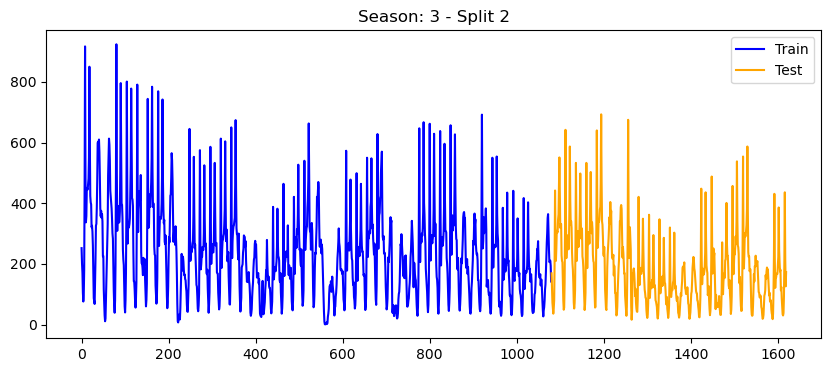

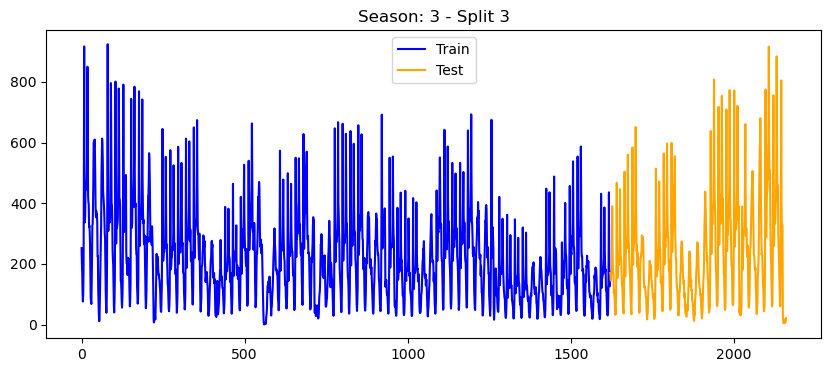

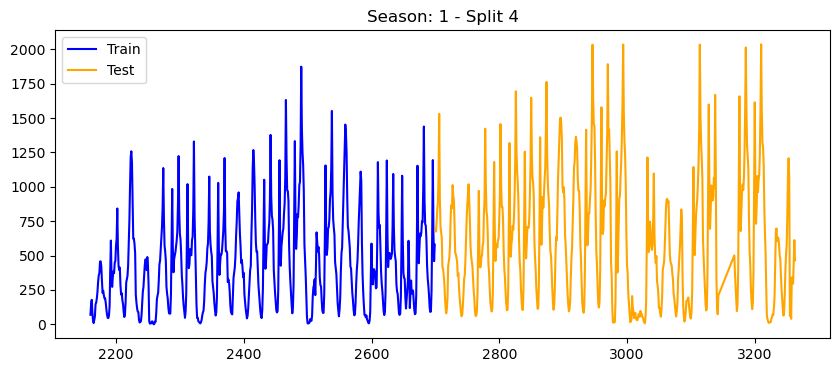

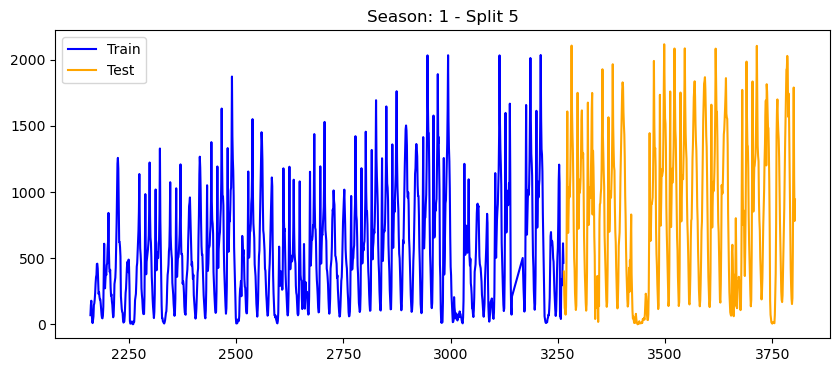

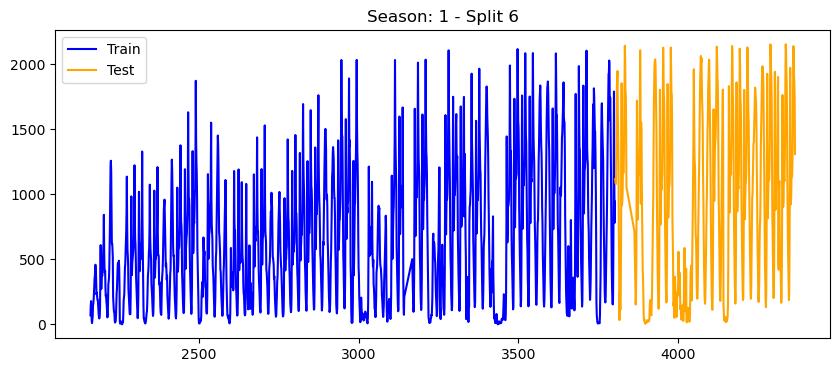

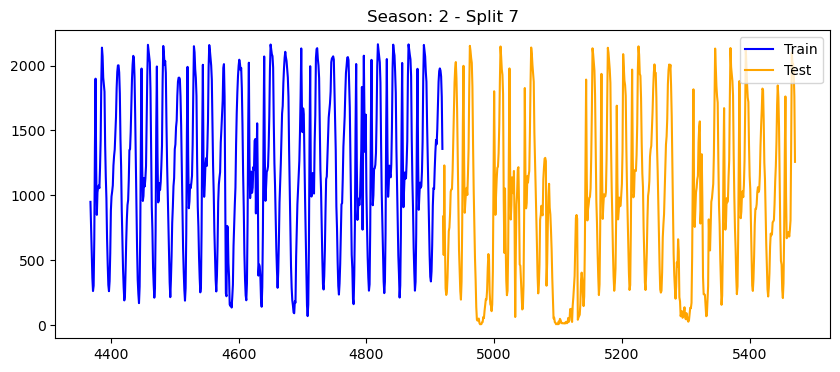

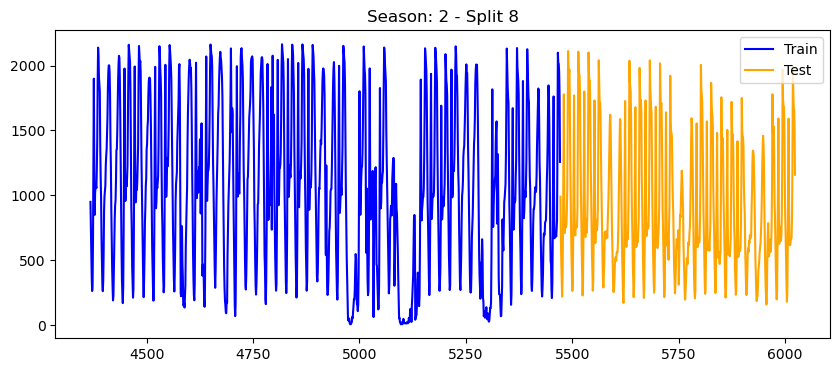

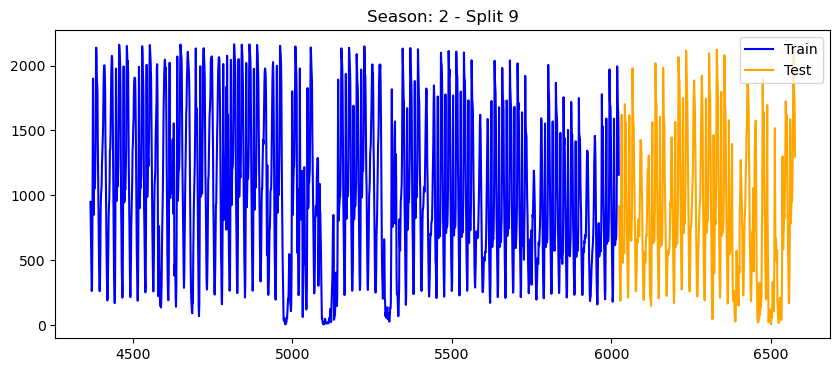

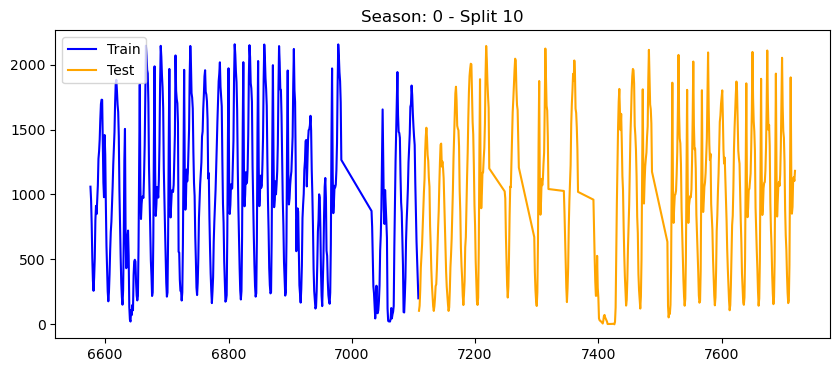

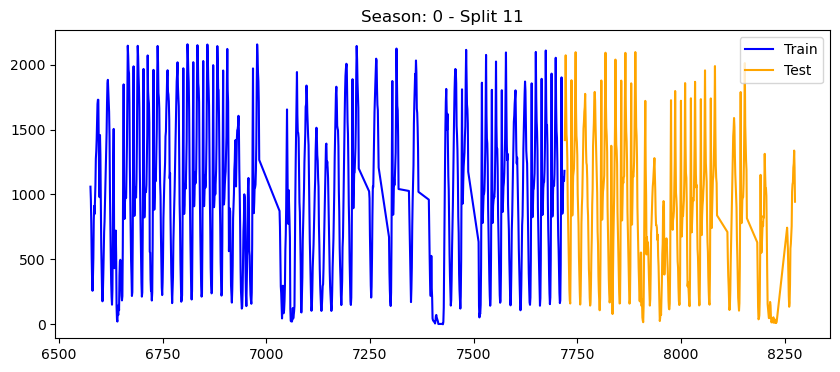

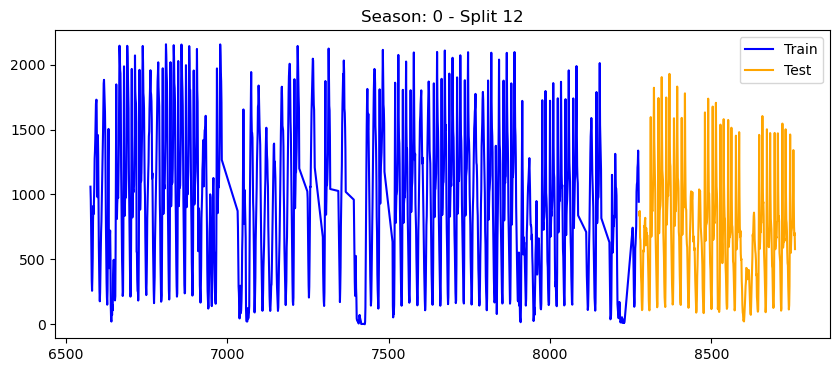

In [39]:
import matplotlib.pyplot as plt

for i, (train_season, test_season) in enumerate(seasonal_splits):
    plt.figure(figsize=(10, 4))
    plt.plot(train_season.index, train_season['Rented Bike Count'], label='Train', color='blue')
    plt.plot(test_season.index, test_season['Rented Bike Count'], label='Test', color='orange')
    plt.title(f"Season: {train_season['Seasons'].iloc[0]} - Split {i+1}")
    plt.legend()
    plt.show()


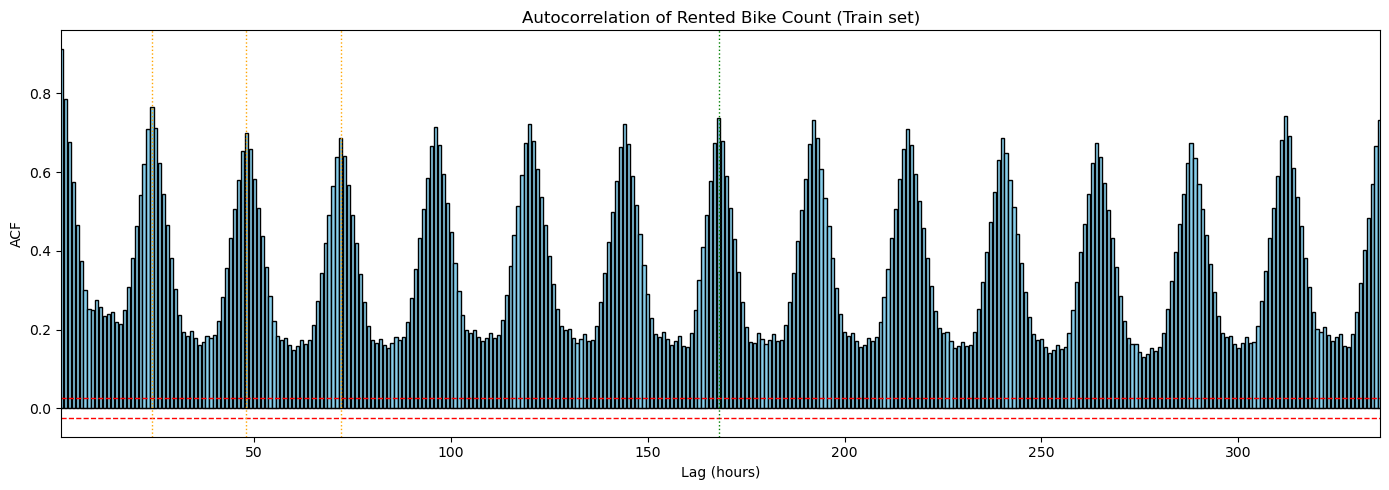

ACF at lag   1:  0.9133
ACF at lag  24:  0.7648
ACF at lag  48:  0.7004
ACF at lag  72:  0.6858
ACF at lag 168:  0.7379


In [45]:
# Autocorrelation analysis for hourly Rented Bike Count

# pick the chronological series (prefer train_data to avoid leakage)
y_series = (train_data['Rented Bike Count']
            if 'train_data' in globals() and 'Rented Bike Count' in train_data
            else data2['Rented Bike Count']).reset_index(drop=True)

max_lag = min(336, len(y_series) - 1)  # up to one week of hourly lags
acf_vals = np.array([y_series.autocorr(lag) for lag in range(1, max_lag + 1)])
conf = 1.96 / np.sqrt(len(y_series))   # ~95% confidence band

plt.figure(figsize=(14, 5))
plt.bar(range(1, max_lag + 1), acf_vals, color='skyblue', edgecolor='k')
plt.hlines([conf, -conf], xmin=1, xmax=max_lag, colors='red', linestyles='--', linewidth=1)
plt.hlines(0, xmin=1, xmax=max_lag, colors='black', linewidth=0.8)

# highlight common seasonal lags
for lag, color in [(24, 'orange'), (48, 'orange'), (72, 'orange'), (168, 'green')]:
    if lag <= max_lag:
        plt.axvline(lag, color=color, linestyle=':', linewidth=1)

plt.title('Autocorrelation of Rented Bike Count (Train set)')
plt.xlabel('Lag (hours)')
plt.ylabel('ACF')
plt.xlim(1, max_lag)
plt.tight_layout()
plt.show()

# quick reference values
for lag in [1, 24, 48, 72, 168]:
    if lag <= max_lag:
        print(f"ACF at lag {lag:>3}: {y_series.autocorr(lag): .4f}")

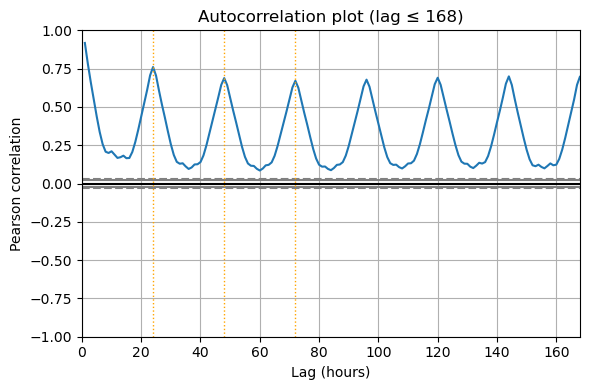

In [65]:
from pandas.plotting import autocorrelation_plot

# Autocorrelation plot using pandas built-in function
plt.figure(figsize=(6, 4))
autocorrelation_plot(data_labeled['Rented Bike Count'])

plt.xlim(0, 168)
plt.title("Autocorrelation plot (lag ≤ 168)")
plt.xlabel("Lag (hours)")
plt.ylabel("Pearson correlation")
plt.axvline(24, color='orange', linestyle=':', linewidth=1)
plt.axvline(48, color='orange', linestyle=':', linewidth=1)
plt.axvline(72, color='orange', linestyle=':', linewidth=1)
plt.tight_layout()
plt.show()




We can see the clear 